<a href="https://colab.research.google.com/github/nmreimer/461GraphMLProject/blob/main/qwen_untuned_7B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
files.upload()  # pick test_qwen_BBB_lora.py
!python /content/test_qwen_BBB_lora.py


Saving test_qwen_BBB_lora.py to test_qwen_BBB_lora.py
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py", line 479, in cached_files
    hf_hub_download(
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py", line 106, in _inner_fn
    validate_repo_id(arg_value)
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py", line 160, in validate_repo_id
    raise HFValidationError(
huggingface_hub.errors.HFValidationError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: './qwen2_1.5B_bbbp_lora'.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/test_qwen_BBB_lora.py", line 201, in <module>
    main()
  File "/content/test_qwen_BBB_lora.py", line 166, in main
    model, tokenizer = load_model_and_tokenizer()
               

In [3]:
from google.colab import files
import os, shutil, glob

%cd /content
!mkdir -p data

uploaded = files.upload()  # select BOTH: few_shot_examples.csv AND BBBP_test_data.csv

# move/rename regardless of duplicate suffixes like "(1).csv"
for fname in uploaded.keys():
    if "few_shot" in fname:
        shutil.move(f"/content/{fname}", "data/few_shot_examples.csv")
    elif "BBBP" in fname and "test" in fname:
        shutil.move(f"/content/{fname}", "data/BBBP_test_data.csv")

!ls -lah data



/content


Saving BBBP_test_data.csv to BBBP_test_data.csv
Saving few_shot_examples.csv to few_shot_examples.csv
total 24K
drwxr-xr-x 2 root root 4.0K Nov 19 20:06 .
drwxr-xr-x 1 root root 4.0K Nov 19 20:06 ..
-rw-r--r-- 1 root root  12K Nov 19 20:06 BBBP_test_data.csv
-rw-r--r-- 1 root root  604 Nov 19 20:06 few_shot_examples.csv


In [1]:
import torch
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import json
import re


DATA_PATH = "data/few_shot_examples.csv"      # few-shot examples
TEST_DATA_PATH = "data/BBBP_test_data.csv"   # test data

# --- NEW CONFIG SWITCHES ---
USE_TUNED = False   # set False to use the untuned (pretrained) baseline
MODEL_FAMILY = "qwen"  # "qwen" or "llama"

# If USE_TUNED=True, load your LoRA folder; otherwise load a HF model id
TUNED_MODEL_DIR = "./qwen2_1.5B_bbbp_lora"
BASE_MODEL_ID = "Qwen/Qwen2-7B-Instruct"   # <- untuned baseline

use_few_shot = True         # keep as is
MAX_LENGTH   = 1024

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SHOTS = [0, 2, 4, 6, 8]   # run all k's

def build_few_shot_prompt(smiles_query, df_examples=None, k=4):
    """
    Build a chat-style prompt with:
    - BBB background message
    - k few-shot examples (if provided)
    - query molecule
    Output format is JSON: {"answer": 0 or 1}
    """
    bbb_background = (
        "The blood-brain barrier (BBB) is a selective barrier that restricts the passage "
        "of most molecules from the bloodstream into the brain. BBB-penetrant molecules "
        "are often moderately lipophilic, relatively small, and avoid strong ionization "
        "and extensive hydrogen bonding at physiological pH. Highly polar or large "
        "molecules usually show poor BBB permeability."
    )

    system_msg = (
        "You are an expert medicinal chemist. "
        "You classify molecules as BBB-penetrant (1) or non-penetrant (0). "
        "Use your knowledge of the BBB and any labeled examples provided."
    )

    # Base query
    user_query = (
        "Analyze the following molecule and predict whether it can cross the "
        "blood-brain barrier (BBB).\n\n"
        f"SMILES: {smiles_query}\n\n"
        "Respond ONLY with a JSON object in the following format:\n\n"
        '{\n'
        '  "answer": <answer>\n'
        '}\n\n'
        "Use 0 for non-BBB-penetrant and 1 for BBB-penetrant. Do not include any "
        "additional text, explanations, or comments outside the JSON object.\n"
    )

    if df_examples is not None:
        examples_text = []
        # Expect columns "SMILES" and "Label" in the few-shot CSV
        for _, row in df_examples.iterrows():
            smiles = row["SMILES"]
            label = int(row["Label"])
            examples_text.append(
                "Example:\n"
                f"SMILES: {smiles}\n"
                f'Output JSON: {{"answer": {label}}}\n'
            )
        few_shot_block = "\n".join(examples_text)
        prompt = (
            f"<|system|>\n{system_msg}\n\n"
            f"Background about BBB:\n{bbb_background}\n\n"
            "<|user|>\n"
            "Here are some labeled examples:\n\n"
            f"{few_shot_block}\n\n"
            f"{user_query}"
            "<|assistant|>\n"
        )
    else:
        prompt = (
            f"<|system|>\n{system_msg}\n\n"
            f"Background about BBB:\n{bbb_background}\n\n"
            "<|user|>\n"
            f"{user_query}"
            "<|assistant|>\n"
        )
    return prompt


from transformers import AutoModelForCausalLM, AutoTokenizer
import torch


def load_model_and_tokenizer():
    model_id_or_path = TUNED_MODEL_DIR if USE_TUNED else BASE_MODEL_ID

    tokenizer = AutoTokenizer.from_pretrained(model_id_or_path, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    model = AutoModelForCausalLM.from_pretrained(
        model_id_or_path,
        device_map="auto",                     # keep auto dispatch
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        trust_remote_code=True,
    )
    model.eval()
    return model, tokenizer                   # <-- no .to(DEVICE)




def parse_json_answer(gen_text: str):
    """
    Extract {"answer": 0/1} from the model's output.
    Returns (prediction:int|None, json_str:str|None).
    """
    # Find the first {...} block
    match = re.search(r"\{.*?\}", gen_text, re.DOTALL)
    if not match:
        return None, None

    json_str = match.group(0)
    try:
        obj = json.loads(json_str)
    except json.JSONDecodeError:
        return None, json_str

    ans = obj.get("answer", None)
    if ans in (0, 1, "0", "1"):
        return int(ans), json_str
    else:
        return None, json_str


def predict_bbb(smiles: str, model, tokenizer, df_examples: pd.DataFrame | None, k: int = 4):
    # choose k-shot examples
    examples = df_examples.head(k) if (df_examples is not None and use_few_shot and k > 0) else None
    prompt = build_few_shot_prompt(smiles, examples, k=k)

    # tokenize (do NOT .to(DEVICE) when using device_map="auto")
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    input_ids = inputs["input_ids"]
    input_len = input_ids.shape[-1]       # <<< define this before generate

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=16,             # small JSON, keep this tight
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    # slice off the prompt portion
    gen_ids = outputs[0, input_len:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    # parse strict JSON first
    prediction, json_str = parse_json_answer(gen_text)

    # OPTIONAL: do NOT force a label if parsing failed; log None instead
    # If you still want a weak fallback, uncomment below:
    # if prediction is None:
    #     for ch in gen_text:
    #         if ch in ("0", "1"):
    #             prediction = int(ch)
    #             break

    return prediction, gen_text



def main():
    # Load model + tokenizer
    model, tokenizer = load_model_and_tokenizer()

    # Load few-shot pool once
    df_examples = pd.read_csv(DATA_PATH) if use_few_shot else None
    if df_examples is not None:
        df_examples["Label"] = df_examples["Label"].astype(int)

    # Load test set once
    test_df = pd.read_csv(TEST_DATA_PATH)
    test_df["True_Label"] = test_df["True_Label"].astype(int)

    tag = "lora" if USE_TUNED else "base"
    os.makedirs("predictions", exist_ok=True)

    for k in SHOTS:
        preds = []
        # use examples only when k>0
        few = df_examples.head(k) if (df_examples is not None and k > 0) else None

        for _, row in test_df.iterrows():
            smiles = row["SMILES"]
            pred_label, raw_output = predict_bbb(
                smiles, model, tokenizer, df_examples=few, k=k
            )
            preds.append({
                "SMILES": smiles,
                "True_Label": row["True_Label"],
                "Predicted_Label": pred_label,
                "Raw_Output": raw_output,
            })

        out = pd.DataFrame(preds)
        # embed metadata + save per-k
        out["k"] = k
        out["model"] = tag
        outpath = f"predictions/qwen2_1.5B_{tag}_{k}_shots_predictions.csv"
        out.to_csv(outpath, index=False)
        print("wrote", outpath)


if __name__ == "__main__":
    main()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [11]:
import pandas as pd
pd.read_csv("/content/predictions/qwen2_1.5B_base_8_shots_predictions.csv").head()


,SMILES,True_Label,Predicted_Label,Raw_Output,k,model
0,CCOC(=O)[C@H](CCc1ccccc1)N[C@@H](C)C(=O)N2CCC[...,0,1,"{\n ""answer"": 1\n}",8,base
1,FC(F)(F)[C@]1(OC(=O)Nc2ccc(Cl)cc12)C#CC3CC3,0,0,"{\n ""answer"": 0\n}",8,base
2,CN1C[C@@H](C[C@H]2[C@H]1Cc3c[nH]c4cccc2c34)C(=...,0,0,"{\n ""answer"": 0\n}",8,base
3,CN1CCC[C@H]1c2cccnc2,1,0,"{\n ""answer"": 0\n}",8,base
4,CN1CCC(=CC1)c2ccccc2,1,0,"{\n ""answer"": 0\n}",8,base


,model,k,n,TP,FP,FN,TN,precision,recall,f1,csv
0,untuned,0,204,0,0,107,97,0.0,0.0,0.0,qwen2_1.5B_base_0_shots_predictions.csv
1,untuned,2,204,0,2,107,95,0.0,0.0,0.0,qwen2_1.5B_base_2_shots_predictions.csv
2,untuned,4,204,0,0,107,97,0.0,0.0,0.0,qwen2_1.5B_base_4_shots_predictions.csv
3,untuned,6,204,0,4,107,93,0.0,0.0,0.0,qwen2_1.5B_base_6_shots_predictions.csv
4,untuned,8,204,0,1,107,96,0.0,0.0,0.0,qwen2_1.5B_base_8_shots_predictions.csv


Saved metrics to: /content/predictions/metrics_summary.csv


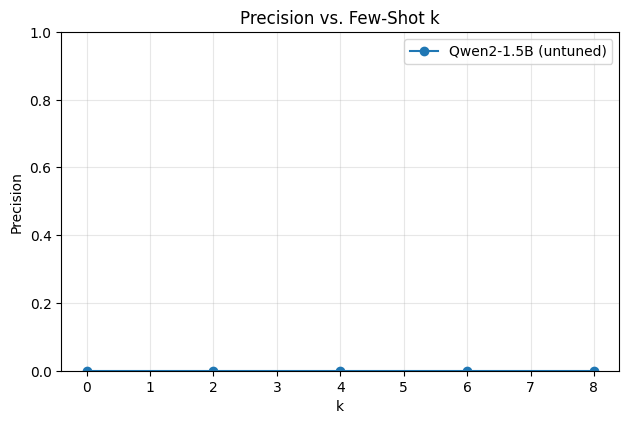

In [12]:
import pandas as pd, numpy as np, os, re, glob
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

PRED_DIR = "/content/predictions"
SHOTS = [0, 2, 4, 6, 8]

def parse_k(name: str):
    # works for ..._8_shots_predictions.csv or ..._8_shots_predictions_untuned.csv
    m = re.search(r'_(\d+)_shots(?:_predictions)?', name)
    return int(m.group(1)) if m else None

def model_tag(name: str):
    n = name.lower()
    # explicit suffix beats prefix words
    if re.search(r'(?:^|_)untuned(?:_|\.|$)', n) or "base" in n:
        return "untuned"
    if re.search(r'(?:^|_)tuned(?:_|\.|$)', n):
        return "tuned"
    # if not explicitly labeled, infer: 'lora' without 'untuned' -> tuned
    if "lora" in n and "untuned" not in n:
        return "tuned"
    return "untuned"

rows = []
seen = set()

for k in SHOTS:
    # match both with/without extra suffix after 'predictions'
    patterns = [
        os.path.join(PRED_DIR, f"*_{k}_shots*_predictions*.csv"),
        os.path.join(PRED_DIR, f"*_{k}_shots_predictions*.csv"),
    ]
    files = []
    for pat in patterns:
        files.extend(glob.glob(pat))

    if not files:
        print(f"[MISSING] no CSV found for k={k}")
        continue

    for f in sorted(set(files)):
        name = os.path.basename(f)
        this_k = parse_k(name)
        if this_k != k:
            continue

        tag = model_tag(name)
        key = (tag, this_k)
        if key in seen:    # avoid duplicates if multiple patterns matched the same k
            continue
        seen.add(key)

        df = pd.read_csv(f)
        if not {"True_Label","Predicted_Label"}.issubset(df.columns):
            print(f"[WARN] missing cols in {name}; skipping")
            continue

        y_true = df["True_Label"].astype(int)
        y_pred = df["Predicted_Label"].astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

        rows.append({
            "model": tag, "k": k, "n": len(df),
            "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall":    recall_score(y_true, y_pred, zero_division=0),
            "f1":        f1_score(y_true, y_pred, zero_division=0),
            "csv": name
        })

summary = pd.DataFrame(rows).sort_values(["model","k"]).reset_index(drop=True)
display(summary)

# save + quick plot
os.makedirs(PRED_DIR, exist_ok=True)
out = os.path.join(PRED_DIR, "metrics_summary.csv")
summary.to_csv(out, index=False)
print("Saved metrics to:", out)

if not summary.empty:
    import matplotlib.pyplot as plt
    piv = summary.pivot(index="k", columns="model", values="precision").sort_index()
    plt.figure(figsize=(7.2,4.4))
    for col, label in [("tuned","Qwen2-1.5B (tuned)"), ("untuned","Qwen2-1.5B (untuned)")]:
        if col in piv.columns:
            plt.plot(piv.index, piv[col], marker="o", label=label)
    plt.title("Precision vs. Few-Shot k"); plt.xlabel("k"); plt.ylabel("Precision")
    plt.ylim(0,1); plt.grid(True, alpha=.3); plt.legend(); plt.show()


In [10]:
from google.colab import files
files.download("/content/predictions/qwen2_1.5B_bbbp_lora_8_shots_predictions_untuned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from google.colab import files
files.download("/content/predictions/metrics_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# --- config switches you already have above ---
USE_TUNED = False   # False=untuned baseline, True=LoRA-tuned
MODEL_FAMILY = "qwen"  # keep "qwen" for Qwen2-1.5B
SHOTS = [0, 2, 4, 6, 8]

def run_all_k():
    import os, pandas as pd
    os.makedirs("predictions", exist_ok=True)

    model, tokenizer = load_model_and_tokenizer()

    # load data once
    df_examples = pd.read_csv("data/few_shot_examples.csv")
    test_df    = pd.read_csv("data/BBBP_test_data.csv")

    tag = "lora" if USE_TUNED else "base"

    for k in SHOTS:
        preds = []
        for _, row in test_df.iterrows():
            smiles = row["SMILES"]
            use_df = df_examples if k > 0 else None
            pred_label, raw_output = predict_bbb(smiles, model, tokenizer,
                                                 df_examples=use_df, k=k)
            preds.append({
                "SMILES": smiles,
                "True_Label": row["True_Label"],
                "Predicted_Label": pred_label,
                "Raw_Output": raw_output
            })
        out = pd.DataFrame(preds)
        out.to_csv(f"predictions/qwen2_1.5B_{tag}_{k}_shots_predictions.csv", index=False)
        print(f"wrote predictions/qwen2_1.5B_{tag}_{k}_shots_predictions.csv")

if __name__ == "__main__":
    run_all_k()


NameError: name 'load_model_and_tokenizer' is not defined